
# Part 3 — Broadcasting

## The problem broadcasting solves

Element-wise operations require both arrays to have the **same shape**. But very often, you want to combine a big array with a smaller one — for example:

- Add a fixed bonus of 10 runs to every score in the entire `(5, 14)` squad array
- Apply a different adjustment to each player (5 values) across all 14 matches
- Apply a different adjustment to each match (14 values) across all 5 players

None of these involve two arrays of the same shape. **Broadcasting** is the set of rules NumPy uses to "stretch" smaller arrays so they fit a larger one, without actually copying any data in memory.

---

## Broadcasting rule 1: scalar with array

You already used this in Session 5.1 without naming it:

```python
squad_scores + 10
```

The scalar `10` is broadcast to match every position in the `(5, 14)` array. This is the simplest case of broadcasting.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
print("Done")

Done


In [3]:
PLAYERS = ["Virat", "Rohit", "Hardik", "Shubman", "Shreyas"]

squad_scores = np.array([
    [72, 45, 88, 31, 64,  0, 103, 52, 19, 77, 41, 93, 28, 66],   # Virat
    [56,  0, 74, 88, 32, 45,  61, 17, 90, 38, 72,  5, 83, 49],   # Rohit
    [45, 32,  0, 67, 18, 54,  78, 22, 41, 33, 60, 15, 88, 27],   # Hardik
    [33, 61, 45,  0, 77, 83,  22, 58, 44, 71,  0, 66, 31, 52],   # Shubman
    [88, 14, 57, 72,  0, 38,  91, 43, 66, 22, 84,  0, 47, 73],   # Shreyas
])

# Balls faced per player per match (needed later for strike rate)
balls_faced = np.array([
    [48, 32, 55, 24, 41,  0, 61, 38, 16, 50, 29, 58, 22, 44],
    [39,  0, 50, 56, 25, 33,  42, 14, 58, 27, 49,  6, 54, 35],
    [31, 24,  0, 46, 15, 38,  51, 18, 30, 26, 42, 12, 56, 21],
    [25, 42, 33,  0, 52, 56,  18, 40, 32, 47,  0, 44, 24, 36],
    [56, 12, 39, 48,  0, 28,  60, 31, 44, 17, 53,  0, 34, 47],
])

print(f"squad_scores shape: {squad_scores.shape}")
print(f"balls_faced shape:  {balls_faced.shape}")
print()
print("Both arrays have the same shape — this matters for what comes next.")

squad_scores shape: (5, 14)
balls_faced shape:  (5, 14)

Both arrays have the same shape — this matters for what comes next.


In [4]:
# Scalar broadcasting — the simplest case

print("Original shape:", squad_scores.shape)
print()

bonus_flat = squad_scores + 10
print("squad_scores + 10  (every value gets +10):")
print(bonus_flat)
print()
print("The scalar 10 was 'broadcast' to all 70 positions (5 x 14) automatically.")

Original shape: (5, 14)

squad_scores + 10  (every value gets +10):
[[ 82  55  98  41  74  10 113  62  29  87  51 103  38  76]
 [ 66  10  84  98  42  55  71  27 100  48  82  15  93  59]
 [ 55  42  10  77  28  64  88  32  51  43  70  25  98  37]
 [ 43  71  55  10  87  93  32  68  54  81  10  76  41  62]
 [ 98  24  67  82  10  48 101  53  76  32  94  10  57  83]]

The scalar 10 was 'broadcast' to all 70 positions (5 x 14) automatically.


In [5]:
a = np.array([10,20,30,40,50,60,70,80])

In [6]:
a

array([10, 20, 30, 40, 50, 60, 70, 80])

In [7]:
a+10

array([20, 30, 40, 50, 60, 70, 80, 90])

In [8]:
b = np.random.randint(1,100,(1,3,3))

In [9]:
b

array([[[94, 50, 52],
        [89, 15, 99],
        [30, 79, 98]]], dtype=int32)

In [10]:
b + 25

array([[[119,  75,  77],
        [114,  40, 124],
        [ 55, 104, 123]]], dtype=int32)

## Broadcasting rule 2: 1D array with 2D array

This is where broadcasting gets genuinely useful. Suppose each match had a different **pitch difficulty multiplier** — a single value per match, applied to every player's score in that match.

```
squad_scores shape:        (5, 14)   <- 5 players, 14 matches
pitch_multiplier shape:       (14,)  <- one value per match
```

NumPy compares shapes from the **right side**. `(5, 14)` vs `(14,)` — the trailing dimensions (`14` and `14`) match. So NumPy "stretches" the 1D array across all 5 rows, as if it had been repeated 5 times.

```
Conceptually, pitch_multiplier (14,) becomes:

[[m1, m2, m3, ..., m14],     <- repeated for row 0
 [m1, m2, m3, ..., m14],     <- repeated for row 1
 [m1, m2, m3, ..., m14],     <- repeated for row 2
 [m1, m2, m3, ..., m14],     <- repeated for row 3
 [m1, m2, m3, ..., m14]]     <- repeated for row 4
```

No actual copying happens in memory — NumPy is just clever about reusing the same values — but conceptually this is exactly what happens.

In [11]:
marks = np.array([
    [10, 11, 15], # student 1 (sci, math and eng)
    [11, 14, 12], # student 2 (sci, math and eng)
    [10, 11, 15], # student 1 (sci, math and eng)
    [11, 14, 12] # student 2 (sci, math and eng)
])


In [12]:
marks

array([[10, 11, 15],
       [11, 14, 12],
       [10, 11, 15],
       [11, 14, 12]])

In [13]:
marks.shape

(4, 3)

In [14]:
100 * marks

array([[1000, 1100, 1500],
       [1100, 1400, 1200],
       [1000, 1100, 1500],
       [1100, 1400, 1200]])

In [15]:
max_marks = np.array([15, 20, 15])

In [16]:
max_marks

array([15, 20, 15])

In [17]:
marks.shape

(4, 3)

In [19]:
max_marks.shape

(3,)

In [20]:
marks + max_marks

array([[25, 31, 30],
       [26, 34, 27],
       [25, 31, 30],
       [26, 34, 27]])

 ## Broadcasting rule 3: per-row adjustment (the tricky one)

Now suppose instead we want a **per-player** adjustment — one value per player (5 values), applied across all 14 matches for that player.

```
squad_scores shape:           (5, 14)
player_adjustment shape:         (5,)
```

If we try to broadcast `(5,)` directly against `(5, 14)`, comparing from the right: `14` vs `5` — **these do not match and are not 1**. This will fail.

The fix: reshape the 1D array of 5 values into a **column** — shape `(5, 1)` — using `.reshape(-1, 1)` or by indexing with `[:, np.newaxis]`.

```
squad_scores shape:        (5, 14)
player_adjustment shape:    (5, 1)   <- now a column
```

Comparing from the right: `14` vs `1` (1 always broadcasts) — OK. Then `5` vs `5` — match. This works.

In [21]:
# First, let's see the failure, so the fix makes sense

player_form_rating = np.array([1.15, 1.0, 0.95, 1.05, 1.1])   # one value per player (5,)

print(f"squad_scores shape:        {squad_scores.shape}")
print(f"player_form_rating shape:  {player_form_rating.shape}")
print()

try:
    bad_result = squad_scores * player_form_rating
    print(bad_result)
except ValueError as e:
    print(f"ERROR: {e}")
    print()
    print("NumPy compares shapes from the right: 14 vs 5 — neither matches, neither is 1.")
    print("Broadcasting fails. We need to reshape player_form_rating into a column.")

squad_scores shape:        (5, 14)
player_form_rating shape:  (5,)

ERROR: operands could not be broadcast together with shapes (5,14) (5,) 

NumPy compares shapes from the right: 14 vs 5 — neither matches, neither is 1.
Broadcasting fails. We need to reshape player_form_rating into a column.


In [23]:
 # The fix: reshape into a column vector (5, 1)

player_form_column = player_form_rating.reshape(-1, 1)   # -1 means "figure out this dimension"

print(f"player_form_rating shape:        {player_form_rating.shape}")
print(f"player_form_column shape:        {player_form_column.shape}")
print()
print("player_form_column looks like:")
print(player_form_column)
print()

form_adjusted_scores = squad_scores * player_form_column

print("Form-adjusted scores (each player's row scaled by their own form rating):")
print(form_adjusted_scores.round(1))
print()
print(f"Virat (row 0) form rating: {player_form_rating[0]}  ->  every value in row 0 x {player_form_rating[0]}")
print(f"  Check: {squad_scores[0,0]} x {player_form_rating[0]} = {form_adjusted_scores[0,0]:.2f}")

player_form_rating shape:        (5,)
player_form_column shape:        (5, 1)

player_form_column looks like:
[[1.15]
 [1.  ]
 [0.95]
 [1.05]
 [1.1 ]]

Form-adjusted scores (each player's row scaled by their own form rating):
[[ 82.8  51.7 101.2  35.6  73.6   0.  118.4  59.8  21.8  88.6  47.2 107.
   32.2  75.9]
 [ 56.    0.   74.   88.   32.   45.   61.   17.   90.   38.   72.    5.
   83.   49. ]
 [ 42.8  30.4   0.   63.6  17.1  51.3  74.1  20.9  38.9  31.4  57.   14.2
   83.6  25.6]
 [ 34.6  64.   47.2   0.   80.9  87.2  23.1  60.9  46.2  74.6   0.   69.3
   32.6  54.6]
 [ 96.8  15.4  62.7  79.2   0.   41.8 100.1  47.3  72.6  24.2  92.4   0.
   51.7  80.3]]

Virat (row 0) form rating: 1.15  ->  every value in row 0 x 1.15
  Check: 72 x 1.15 = 82.80


 ### Whiteboard: the broadcasting rules, summarised

NumPy compares two array shapes starting from the **rightmost** dimension and moving left. At each position, the dimensions are compatible if:

1. They are **equal**, or
2. One of them is **1**

If every pair of dimensions satisfies one of these, broadcasting succeeds. If any pair fails both conditions, you get a `ValueError`.

```
  squad_scores        (5, 14)
  scalar                 ()      ->  treated as compatible with anything
  per-match           (14,)      ->  compare:        14 vs 14  OK
  per-player        (5, 1)       ->  compare:  5 vs 5,  1 vs 14 (1 stretches)  OK
  per-player (wrong)   (5,)      ->  compare:        5 vs 14  FAIL
```

**The most common beginner mistake:** trying to broadcast a `(5,)` array against a `(5, 14)` array, expecting it to apply per-row. It does not — NumPy always aligns from the right. You must reshape it to `(5, 1)` first.

**Mental shortcut:**
- A plain 1D array of length 14 broadcasts naturally **across rows** (one value per column).
- To broadcast **down columns** (one value per row), reshape to a column: `.reshape(-1, 1)`.

In [24]:
a = np.array([
    [1, 2, 3, 8],
    [4, 5, 6, 12],
    [7, 8, 10, 9]
])

In [25]:
a

array([[ 1,  2,  3,  8],
       [ 4,  5,  6, 12],
       [ 7,  8, 10,  9]])

In [26]:
a.reshape(4, 3)

array([[ 1,  2,  3],
       [ 8,  4,  5],
       [ 6, 12,  7],
       [ 8, 10,  9]])

In [27]:
a.reshape(4, -1)

array([[ 1,  2,  3],
       [ 8,  4,  5],
       [ 6, 12,  7],
       [ 8, 10,  9]])

In [28]:
a.reshape(-1)

array([ 1,  2,  3,  8,  4,  5,  6, 12,  7,  8, 10,  9])

In [29]:
a.reshape(-1, 1)

array([[ 1],
       [ 2],
       [ 3],
       [ 8],
       [ 4],
       [ 5],
       [ 6],
       [12],
       [ 7],
       [ 8],
       [10],
       [ 9]])

# 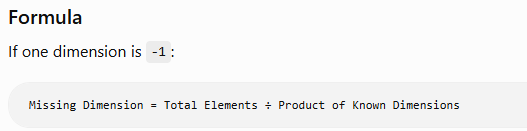

| Code                | Total Elements | Calculated Shape |
| ------------------- | -------------- | ---------------- |
| `reshape(2, -1)`    | 6              | `(2, 3)`         |
| `reshape(-1, 2)`    | 12             | `(6, 2)`         |
| `reshape(3, -1)`    | 12             | `(3, 4)`         |
| `reshape(2, 3, -1)` | 24             | `(2, 3, 4)`      |
| `reshape(-1, -1)`   | ❌              | Error            |



#  — Aggregations: Sum, Mean, Standard Deviation



We briefly used `.sum()` and `.mean()` last time. Today we go deeper, and add **standard deviation** — a measure of consistency that is essential for real analysis.

---

## Sum and Mean — totals and central tendency

In [30]:
print("Sum and Mean:")
print(f"  Total runs, whole squad, whole season: {squad_scores.sum()}")
print(f"  Total runs per player (axis=1):        {squad_scores.sum(axis=1)}")
print(f"  Total runs per match  (axis=0):         {squad_scores.sum(axis=0)}")
print()
print(f"  Average score, whole squad:             {squad_scores.mean():.2f}")
print(f"  Average per player (axis=1):            {squad_scores.mean(axis=1).round(2)}")
print(f"  Average per match  (axis=0):            {squad_scores.mean(axis=0).round(2)}")

Sum and Mean:
  Total runs, whole squad, whole season: 3407
  Total runs per player (axis=1):        [779 710 580 643 695]
  Total runs per match  (axis=0):         [294 152 264 258 191 220 355 192 260 241 257 179 277 267]

  Average score, whole squad:             48.67
  Average per player (axis=1):            [55.64 50.71 41.43 45.93 49.64]
  Average per match  (axis=0):            [58.8 30.4 52.8 51.6 38.2 44.  71.  38.4 52.  48.2 51.4 35.8 55.4 53.4]


## Standard deviation — measuring consistency

**Standard deviation** measures how spread out values are from the mean. A low standard deviation means the values are clustered close to the average — consistent. A high standard deviation means the values are spread out — inconsistent.

### Why this matters for our cricket analysis

Two players can have the exact same average but very different reliability:

```
Player A: 50, 48, 52, 49, 51   ->  mean = 50,  std = very low   (consistent)
Player B: 0, 10, 100, 5, 135   ->  mean = 50,  std = very high  (boom or bust)
```

A team captain might prefer Player A for a tight chase, and Player B as a high-risk, high-reward option. Standard deviation is how you quantify that difference.

In [31]:
# Demonstrating with the example above

player_a = np.array([50, 48, 52, 49, 51])
player_b = np.array([0, 10, 100, 5, 135])

print(f"Player A: {player_a}")
print(f"  mean = {player_a.mean():.1f}   std = {player_a.std():.2f}")
print()
print(f"Player B: {player_b}")
print(f"  mean = {player_b.mean():.1f}   std = {player_b.std():.2f}")
print()
print("Same mean, wildly different standard deviation.")
print("Player A is the reliable, consistent option.")
print("Player B is the unpredictable, high-variance option.")

Player A: [50 48 52 49 51]
  mean = 50.0   std = 1.41

Player B: [  0  10 100   5 135]
  mean = 50.0   std = 56.30

Same mean, wildly different standard deviation.
Player A is the reliable, consistent option.
Player B is the unpredictable, high-variance option.


In [32]:
# Now apply this to our actual squad

means = squad_scores.mean(axis=1)
stds  = squad_scores.std(axis=1)

print("CONSISTENCY REPORT")
print("=" * 55)
print(f"  {'Player':<10} {'Average':>9}  {'Std Dev':>9}  {'Consistency'}")
print("  " + "-" * 50)

for i, player in enumerate(PLAYERS):
    consistency = "Very consistent" if stds[i] < 20 else ("Moderate" if stds[i] < 30 else "Inconsistent")
    print(f"  {player:<10} {means[i]:>9.1f}  {stds[i]:>9.1f}  {consistency}")

print()
most_consistent = PLAYERS[stds.argmin()]
least_consistent = PLAYERS[stds.argmax()]
print(f"Most consistent player:  {most_consistent} (std = {stds.min():.1f})")
print(f"Least consistent player: {least_consistent} (std = {stds.max():.1f})")

CONSISTENCY REPORT
  Player       Average    Std Dev  Consistency
  --------------------------------------------------
  Virat           55.6       29.0  Moderate
  Rohit           50.7       28.6  Moderate
  Hardik          41.4       24.5  Moderate
  Shubman         45.9       25.3  Moderate
  Shreyas         49.6       30.3  Inconsistent

Most consistent player:  Hardik (std = 24.5)
Least consistent player: Shreyas (std = 30.3)


### Exercise 3 — Aggregations

**Task:** Using `squad_scores`, compute the following. Every answer should be one vectorized expression.

In [38]:
# # Q1: Standard deviation of scores for EACH MATCH (across all 5 players)
# #     i.e. how spread out were the team's scores within match 1, match 2, etc.
# match_std = squad_scores.std(axis=___)

# # Q2: Which match had the most inconsistent scores across players?
# #     Hint: use .argmax() on match_std
# most_inconsistent_match = match_std.___() + 1   # <-- which method? (+1 converts to match number)

# # Q3: The overall team standard deviation (single number, entire 2D array)
# overall_std = squad_scores.___()

# # Q4: Range (max - min) of scores for each player
# #     Hint: there's no .range() method — compute it from .max() and .min()
# player_range = squad_scores.max(axis=1) - squad_scores.___(axis=1)


# print(f"Q1 Match std devs:           {match_std.round(1)}")
# print(f"Q2 Most inconsistent match:  Match {most_inconsistent_match}")
# print(f"Q3 Overall team std:         {overall_std:.2f}")
# print(f"Q4 Player ranges:            {player_range}")
# print()
# print(f"Correct Q1 (14 values):  {len(match_std) == 14}")
# print(f"Correct Q4 (5 values):   {len(player_range) == 5}")

 ### Important: `.copy()` matters

When you write `new_array = old_array`, you do **not** get a new array — you get another name pointing to the same data. Modifying `new_array` would also modify `old_array`.

`.copy()` creates an actual independent array. Always use it when you want to modify a version of your data while keeping the original untouched — which is almost always what you want during analysis.

In [39]:
# np.where() revisited — a mask-based way to build a NEW array
# without modifying the original

# Classify every score as 'duck', 'failure', 'starter', 'good', or 'fifty_plus'
# We do this with nested np.where() calls — innermost evaluated first

classification = np.where(
    squad_scores == 0, "duck",
    np.where(
        squad_scores < 20, "failure",
        np.where(
            squad_scores < 40, "starter",
            np.where(
                squad_scores < 50, "good",
                "fifty_plus"
            )
        )
    )
)

print("Classification of Virat's matches:")
for i in range(14):
    print(f"  Match {i+1:>2}: score={squad_scores[0,i]:>3}  ->  {classification[0,i]}")

Classification of Virat's matches:
  Match  1: score= 72  ->  fifty_plus
  Match  2: score= 45  ->  good
  Match  3: score= 88  ->  fifty_plus
  Match  4: score= 31  ->  starter
  Match  5: score= 64  ->  fifty_plus
  Match  6: score=  0  ->  duck
  Match  7: score=103  ->  fifty_plus
  Match  8: score= 52  ->  fifty_plus
  Match  9: score= 19  ->  failure
  Match 10: score= 77  ->  fifty_plus
  Match 11: score= 41  ->  good
  Match 12: score= 93  ->  fifty_plus
  Match 13: score= 28  ->  starter
  Match 14: score= 66  ->  fifty_plus



### Element-wise operations
- Two arrays of the **same shape** combine position by position
- `np.where(condition, value_if_true, value_if_false)` is a vectorized if/else — use it to handle special cases (like division by zero) without loops
- Comparisons (`>`, `<`, `==`) between two same-shaped arrays produce a boolean array, element-wise

### Broadcasting
- Lets arrays of **different shapes** work together by "stretching" the smaller one
- NumPy compares shapes from the **right**: dimensions must be equal, or one of them must be 1
- A 1D array of length matching the last dimension broadcasts naturally across rows
- To broadcast per-row instead, reshape to a column: `.reshape(-1, 1)`
- Failed broadcasts raise a clear `ValueError` — read it carefully, it tells you the shapes involved

### Aggregations
- `.sum()`, `.mean()` — totals and central tendency, with `axis=0` (down columns) or `axis=1` (across rows)
- `.std()` — standard deviation, measures consistency. Low = reliable, high = volatile
- Same mean does not mean same behaviour — always check standard deviation alongside the average

### Masking
- A mask is a boolean array the same shape as your data
- `array[mask]` **selects** matching values (returns a flat 1D array of just the matches)
- `array[mask] = value` **modifies** matching positions in place
- Combine conditions with `&` (and), `|` (or), `~` (not) — always wrap each condition in parentheses
- Always use `.copy()` before modifying an array if you want to preserve the original
- `mask.sum()` counts `True` values (since `True` behaves as `1`)

---

### What comes next

You now have the core vectorized toolkit: element-wise math, broadcasting, aggregation, and masking. These four ideas are the foundation of nearly everything in Pandas, which we move to next — every Pandas Series and DataFrame column is built on exactly these NumPy mechanics, just with row and column labels added on top.

---

### Quick reference

```python
import numpy as np

# Element-wise
a + b                              # same-shape arrays, position by position
np.where(cond, val_true, val_false)  # vectorized if/else

# Broadcasting
arr + scalar                       # scalar broadcasts everywhere
arr_2d * arr_1d                    # 1D broadcasts across rows (matches last dim)
arr_2d * arr_1d.reshape(-1, 1)      # reshaped 1D broadcasts down columns (per-row)

# Aggregations
arr.sum(axis=0)    # down columns
arr.sum(axis=1)    # across rows
arr.mean()
arr.std()          # standard deviation

# Masking
mask = arr > 50                    # boolean array, same shape
arr[mask]                          # select matching values (flat)
arr[mask] = 0                      # modify matching values in place
arr[(arr > 10) & (arr < 50)]       # combine conditions
mask.sum()                         # count True values
arr.copy()                         # independent copy before modifying
```